# GPNAM: Gaussian-process-inspired additive model

GPNAM fixes a random Fourier feature map for each scalar input and estimates only additive coefficients. It approximates RBF-kernel functions but does not produce GP posterior covariance.


## Model in one view


$$
\phi_j(x_j)=\sqrt{\frac{2}{M}}
\left[\cos\!\left(z_mx_j/\ell_j+c_{mj}\right)\right]_{m=1}^{M},
\qquad
\eta(x)=\beta_0+\sum_j\phi_j(x_j)^\top w_j.
$$

Selected pairs add two-dimensional GP-NA2M feature maps.



For a stationary RBF kernel, Bochner's theorem represents the kernel as an
expectation over sinusoidal features. GPNAM samples a finite deterministic
random-feature approximation per input and estimates additive ridge
coefficients in that basis. Kernel width controls the frequency scale and
therefore how rapidly a learned shape may vary.

The resulting estimator is finite-dimensional and computationally cheaper
than an exact Gaussian process. It borrows the GP function-space bias but does
not return a GP posterior or epistemic covariance. Pairwise GP-NA2M blocks use
the same construction on selected two-dimensional inputs.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


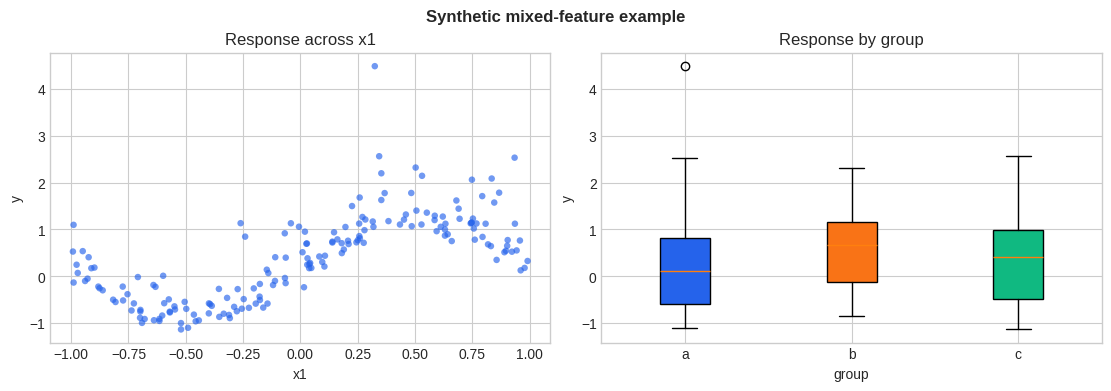

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import GPNAMClassifier, GPNAMLSS, GPNAMRegressor


model = GPNAMRegressor(
    rff_num_feat=32,
    kernel_width="auto",
    solver="cg",
    ridge=0.05,
    interactions=(("x1", "x2"),),
    rff_random_state=7,
)
model.get_params(deep=False)


{'cg_max_iter': None,
 'cg_rtol': 1e-06,
 'interaction_degree': None,
 'interactions': (('x1', 'x2'),),
 'intercept': True,
 'kernel_width': 'auto',
 'kernel_widths': None,
 'lr': 0.01,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'lr_schedule': 'inverse_sqrt',
 'rff_num_feat': 32,
 'rff_random_state': 7,
 'rff_scheme': 'quasi_random',
 'ridge': 0.05,
 'solver': 'cg',
 'weight_decay': 0.0,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'none',
 'categorical_preprocessing': 'one-hot',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 'scaling_strategy': None,
 'n_knots': 64,
 'use_decision_tree_knots': True,
 'knots_strategy': 'uniform',
 'spline_implementation': 'sklearn',
 'min_unique_vals': 5}

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


{'R2': 0.864581994119743, 'Mean Squared Error': 0.09450933184756154}

,term,term_type,output,importance
0,x1,main,0,0.614299
1,x2,main,0,0.343900
2,x1:x2,interaction,0,0.148436
3,group[1],main,0,0.076847
4,group[0],main,0,0.039311
5,group[2],main,0,0.028884


,term,term_type,output,value,value_2,contribution,count,importance
0,x1,main,0,-0.965,NaN,-0.270469,2,0.614299
1,x1,main,0,-0.8895,NaN,-0.411236,2,0.614299
2,x1,main,0,-0.7905,NaN,-0.913361,2,0.614299
3,x1,main,0,-0.6915,NaN,-0.974433,2,0.614299
4,x1,main,0,-0.58,NaN,-1.039463,2,0.614299
5,x1,main,0,-0.4875,NaN,-1.106694,2,0.614299
6,x1,main,0,-0.35,NaN,-0.843397,1,0.614299
7,x1,main,0,-0.209,NaN,-0.773430,2,0.614299
8,x1,main,0,-0.12505,NaN,-0.462443,2,0.614299
9,x1,main,0,-0.05205,NaN,-0.509099,2,0.614299


## Evaluate and explain


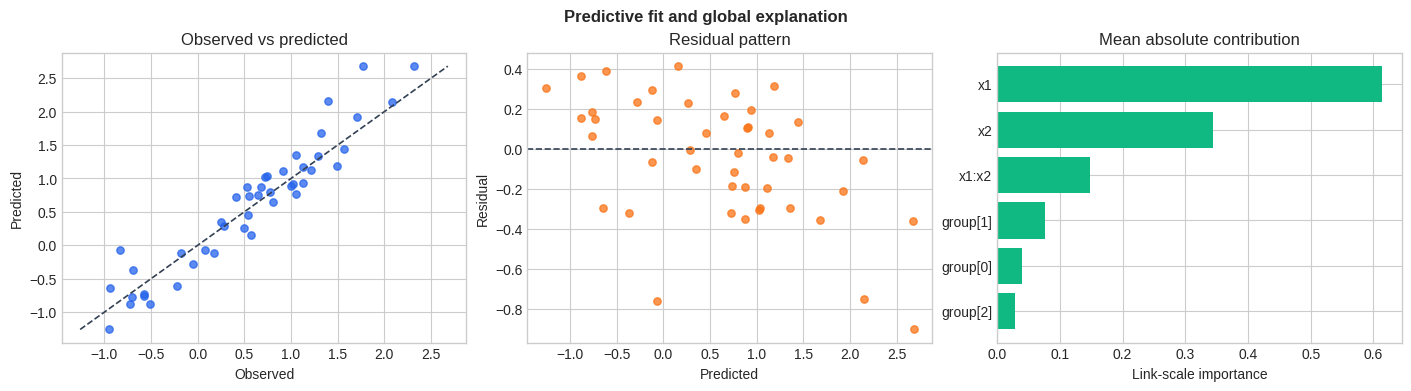

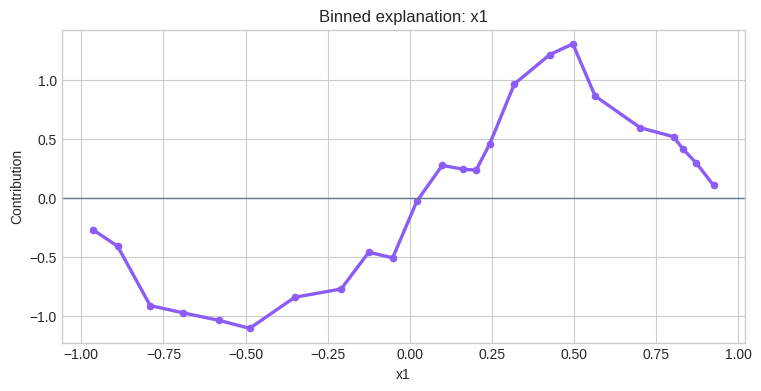

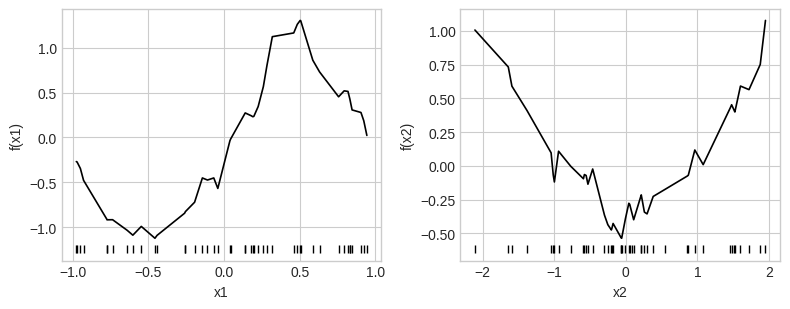

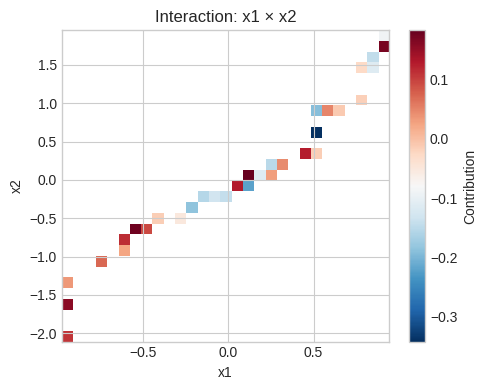

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

Regression defaults to the fixed conjugate-gradient ridge solve. `basis_transform`, `basis_metadata`, and `model_complexity` expose the fitted finite basis.


In [6]:
Phi = model.basis_transform(X_test)
display(Phi.shape)
display(model.basis_metadata())
display(model.model_complexity())
display(model.kernel_widths_)


(45, 192)

{'feature_names': ('x1', 'x2', 'group[0]', 'group[1]', 'group[2]'),
 'interaction_names': ('x1:x2',),
 'kernel_widths': array([0.0236598 , 0.03872994, 0.01936135, 0.01895559, 0.02048844],
       dtype=float32),
 'frequencies': array([-1.8763584 , -1.5497059 , -1.3351777 , -1.1689488 , -1.0299568 ,
        -0.9084579 , -0.79908276, -0.69852567, -0.60458535, -0.51570475,
        -0.43072724, -0.34875566, -0.2690661 , -0.19105197, -0.11418526,
        -0.03798831,  0.03798831,  0.11418533,  0.19105197,  0.26906618,
         0.34875566,  0.43072733,  0.51570475,  0.6045854 ,  0.69852567,
         0.7990828 ,  0.9084579 ,  1.0299568 ,  1.1689488 ,  1.3351779 ,
         1.5497059 ,  1.876359  ], dtype=float32),
 'phases': array([[2.9452431 , 2.159845  , 0.5890486 , 1.1780972 , 3.7306414 ,
         3.926991  , 4.1233406 , 0.19634955, 2.3561945 , 3.1415927 ,
         5.8904862 , 4.712389  , 0.98174775, 4.31969   , 1.7671459 ,
         5.6941366 , 5.105088  , 1.3744469 , 5.301438  , 1.9634955 ,

{'total_parameters': 193, 'trainable_parameters': 193}

array([0.0236598 , 0.03872994, 0.01936135, 0.01895559, 0.02048844],
      dtype=float32)

## Supported task variants

`GPNAMClassifier` and `GPNAMLSS` use gradient training. Distributional uncertainty is aleatoric, not GP posterior uncertainty.


In [7]:
task_variants = {"regression": GPNAMRegressor(), "classification": GPNAMClassifier(), "distributional": GPNAMLSS()}


## References

- [Gaussian Process Neural Additive Models (2024)](https://arxiv.org/abs/2402.12518).
